## Raport 3
### Komputerowe symulacje procesów stochastycznych

Autorzy
* Krzysztof Dobrzański (242504)
* Bartosz Michalak (268429)

In [35]:
import numpy as np
import math
from scipy.stats import linregress, wasserstein_distance
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
from numba import njit

np.random.seed(42)

traj_color_count = 6
cmap = mcolors.LinearSegmentedColormap.from_list(
    "trajectories_gradient",
    ["#3333ff", "#ff33ff"]
)
traj_colors = [cmap(i/(traj_color_count-1)) for i in range(traj_color_count)]

plt.style.use("dark_background")
# plt.rcParams["text.color"] = "#eeeeee"
# plt.rcParams["axes.labelcolor"] = "#eeeeee"
# plt.rcParams["xtick.color"] = "#eeeeee"
# plt.rcParams["ytick.color"] = "#eeeeee"
# plt.rcParams["axes.titlecolor"] = "#eeeeee"

In [36]:
def get_proc_stats(processes):
    mean = np.zeros_like(processes[0])
    var = np.zeros_like(processes[0])
    q95 = np.zeros_like(processes[0])
    q05 = np.zeros_like(processes[0])

    for p in processes:
        mean += p
    mean = mean/len(processes)
    
    for p in processes:
        var += (mean - p)**2
    var = var/len(processes)

    for t in range(0, len(processes[0])):
        vals_at_t = []
        for p in processes:
            vals_at_t.append(p[t])
        vals_at_t = np.sort(vals_at_t)
        q95[t] = vals_at_t[ int( 0.95*len(processes) ) ]
        q05[t] = vals_at_t[ int( 0.05*len(processes) ) ]

    return mean, var, q05, q95


@njit
def get_msd(processes):
    proc_len = len(processes[0])
    eamsd = np.zeros(proc_len, dtype=np.float64)
    eatamsd = np.zeros(proc_len, dtype=np.float64)
    
    # EAMSD
    for t in range(0, proc_len):
        sq_diff_sum = 0.0
        for traj in processes:
            sq_diff_sum += (traj[t] - traj[0])**2
        eamsd[t] = sq_diff_sum / len(processes)
        
    # EATAMSD
    for lag in range(0, proc_len):
        if lag == 0:
            eatamsd[lag] = 0.0
            continue
        
        total_tamsd_sum = 0.0
        count = proc_len - lag
        
        for traj in processes:
            tamsd_single_sum = 0.0
            for t in range(count):
                tamsd_single_sum += (traj[t + lag] - traj[t])**2
            total_tamsd_sum += tamsd_single_sum / count
            
        eatamsd[lag] = total_tamsd_sum / len(processes)
        
    return eamsd, eatamsd


def get_codifference(X, Y):
    return (np.log(np.mean( np.exp(1j*(X - Y)) )) - np.log(np.mean( np.exp(1j*X) )) - np.log(np.mean( np.exp(-1j*Y) ))).real


def get_auto_codifference(X):
    return np.array([get_codifference(X[:-h], X[h:]) for h in range(1, len(X) - 1)])


def get_covariance(X, Y):
    return np.mean(X * Y) - np.mean(X) * np.mean(Y)


def get_auto_covariance(X):
    return np.array([get_covariance(X[:-h], X[h:]) for h in range(1, len(X) - 1)])

### Ułamkowy ruch Browna


In [37]:
@njit
def get_rand_normal_vec(mean, cov, n_samples=1):
    dims = mean.shape[0]
    z = np.random.randn(n_samples, dims)
    A = np.linalg.cholesky(cov)

    return mean + z @ A.T


@njit
def tepl_cov(i, j, H, dt):
    diff = i - j
    H *= 2.0
    return (dt**H)/2.0 * (abs(diff + 1.0)**H + abs(diff - 1.0)**H - 2.0*abs(diff)**H)


@njit
def simulate_fbm_teplic(dt, sim_len: int, H, mean):
    cov_mat = np.zeros((sim_len, sim_len))
    for i in range(0, sim_len):
        for j in range(0, sim_len):
            cov_mat[i][j] = tepl_cov(i, j, H, dt)

    increments = get_rand_normal_vec(np.zeros(sim_len), cov_mat, 1)

    return np.cumsum(increments), cov_mat

Simulating trajectories:   0%|          | 0/2 [00:00<?, ?it/s]

Simulating trajectories: 100%|██████████| 2/2 [00:02<00:00,  1.08s/it]


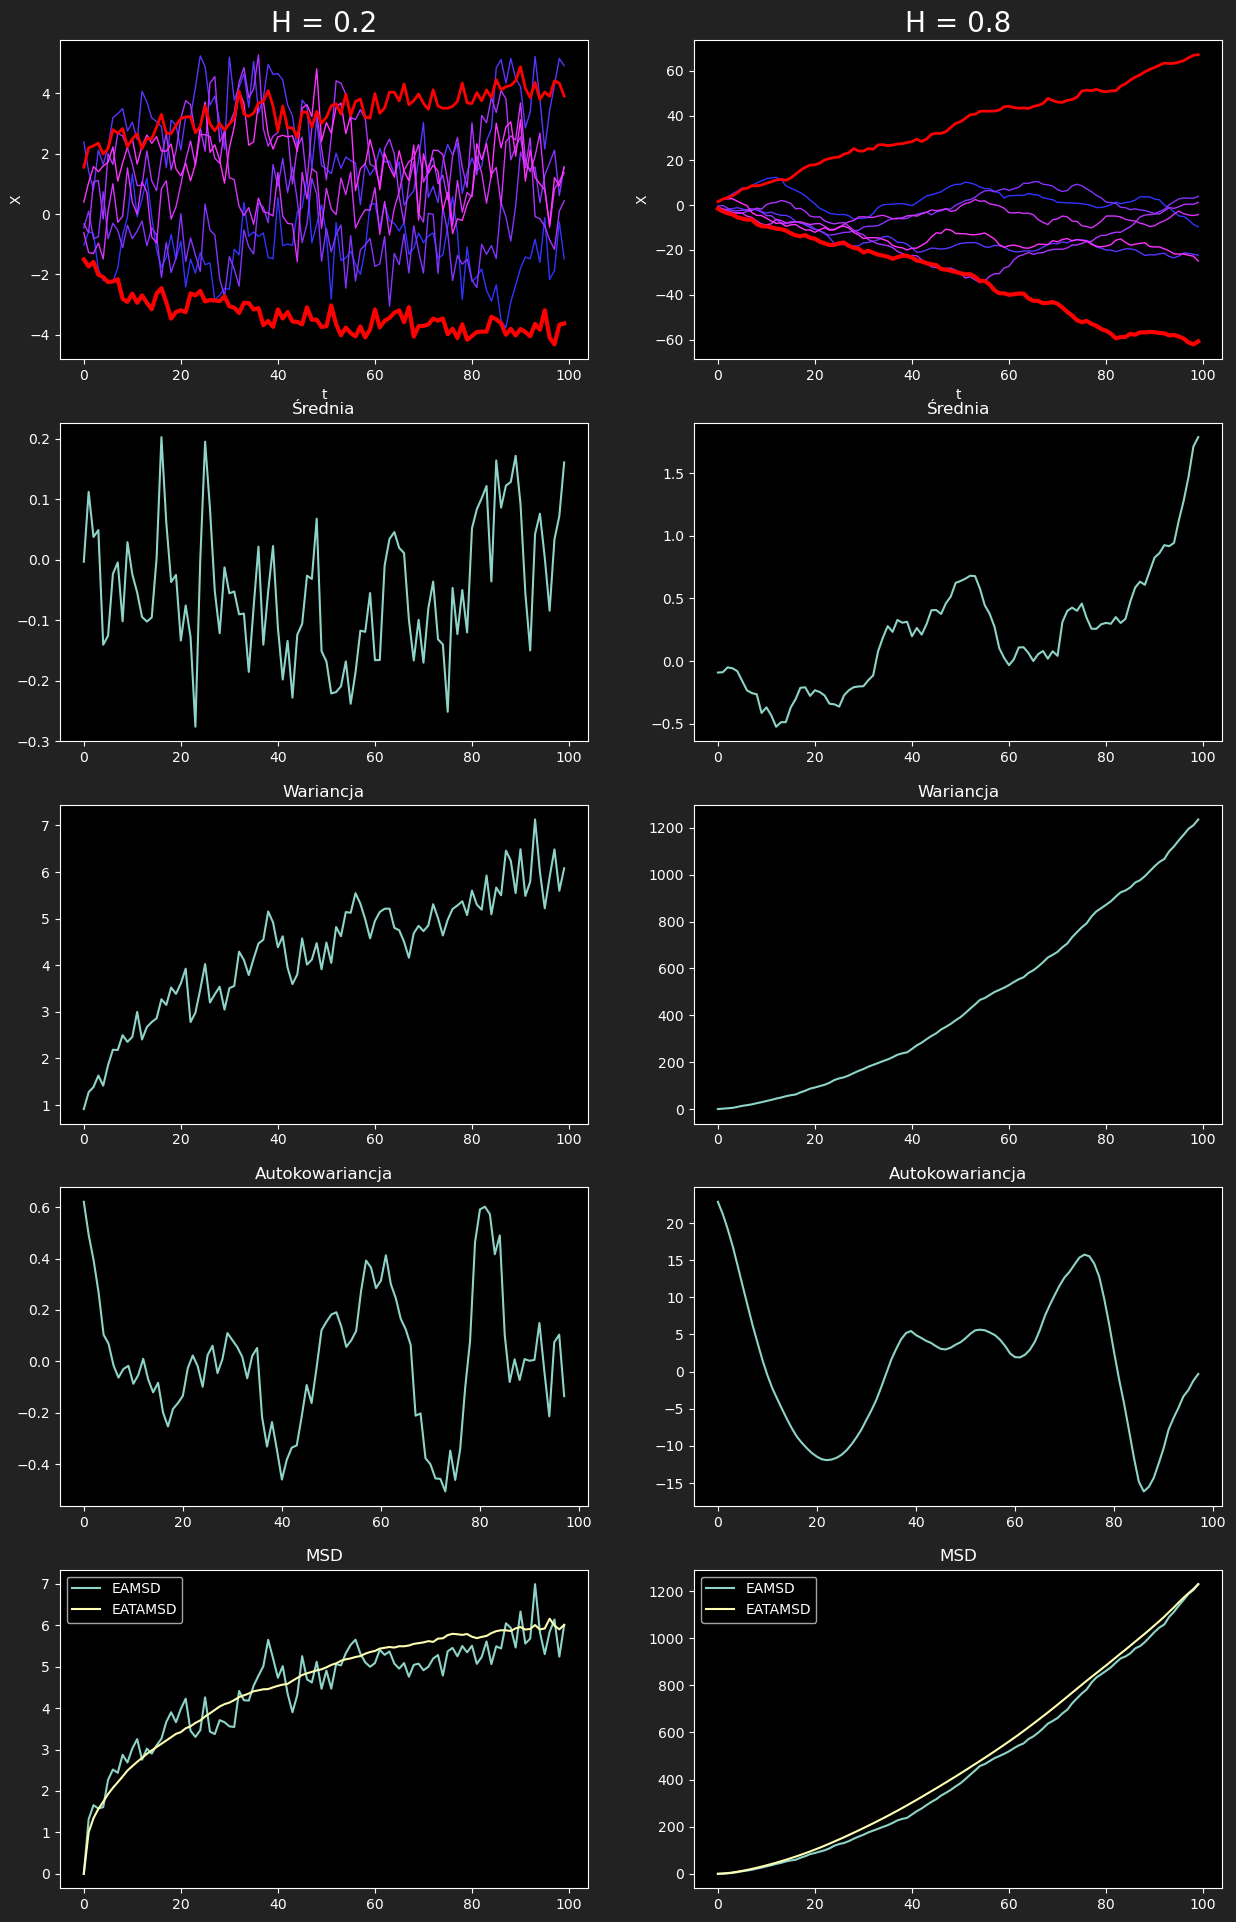

In [38]:
    H_vals = [0.2, 0.8]
    trajectories_count = 1000
    draw_trajectories = 6
    sim_len = 1000
    dt = 1.0

    fig, axes = plt.subplots(5, 2, figsize=(15, 24), facecolor="#222222")

    for i, H in enumerate(tqdm(H_vals, desc=f"Simulating trajectories: ")):
        proc_vals = []

        for j in range(0, trajectories_count):
            sim_v, _ = simulate_fbm_teplic(dt, sim_len, H, 0.0)
            proc_vals.append(sim_v)
            if j < draw_trajectories:
                axes[0, i].plot(sim_v, linewidth=1, color=traj_colors[j])


        mean, var, q05, q95 = get_proc_stats(proc_vals)
        a_cod = get_auto_codifference(proc_vals[0])
        a_cov = get_auto_covariance(proc_vals[0])
        eamsd, eatamsd = get_msd(proc_vals)

        axes[0, i].plot(q05, color="red", label="Linie kwantylowe", linewidth=3)
        axes[0, i].plot(q95, color="red", linewidth=2)
        axes[0, i].set_xlabel("t")
        axes[0, i].set_ylabel("X")
        axes[0, i].set_title(f"H = {H}", fontsize=20)

        axes[1, i].plot(mean)
        axes[1, i].set_title("Średnia")
        
        axes[2, i].plot(var)
        axes[2, i].set_title("Wariancja")

        axes[3, i].plot(a_cov)
        axes[3, i].set_title("Autokowariancja")

        axes[4, i].plot(eamsd, label="EAMSD")
        axes[4, i].plot(eatamsd, label="EATAMSD")
        axes[4, i].set_title("MSD")
        axes[4, i].legend()

    plt.show()

## Zagadnienia (ułamkowy ruch Browna)

#### Czy proces jest stacjonarny?

Nie, ponieważ linie kwantylowe nie są poziome.

#### Czy przyrosty procesu są stacjonarne?



#### Jaki jest rozkład procesu w ustalonej chwili czasu? Jaki jest rozkład przyrostów?


#### Czy EATAMSD pokrywa się z EAMSD?


#### Czy proces jest samopodobny? Czy jego przyrosty są samopodobne?



### Ułamkowy proces Ornsteina-Uhlenbecka

In [39]:
@njit
def get_a_stable_process_arbitrary_t(a, B, time_points):
    increments = np.zeros_like(time_points)
    for i in range(1, len(time_points)):
        dt = time_points[i] - time_points[i - 1]
        sigma = (dt)**(1/a)
        increments[i] = rand_a_stable(a, B, sigma, 0.0)
    return np.cumsum(increments)


@njit
def get_lamperti_transformed_proc(a, B, proc_len, dt):
    t = np.arange(0, proc_len) * dt
    t_sc = np.exp(t)
    proc = get_a_stable_process_arbitrary_t(a, B, t_sc)
    proc_sc = np.exp(-1.0/a*t)
    return proc*proc_sc

Simulating trajectories:   0%|          | 0/2 [00:00<?, ?it/s]

Simulating trajectories: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


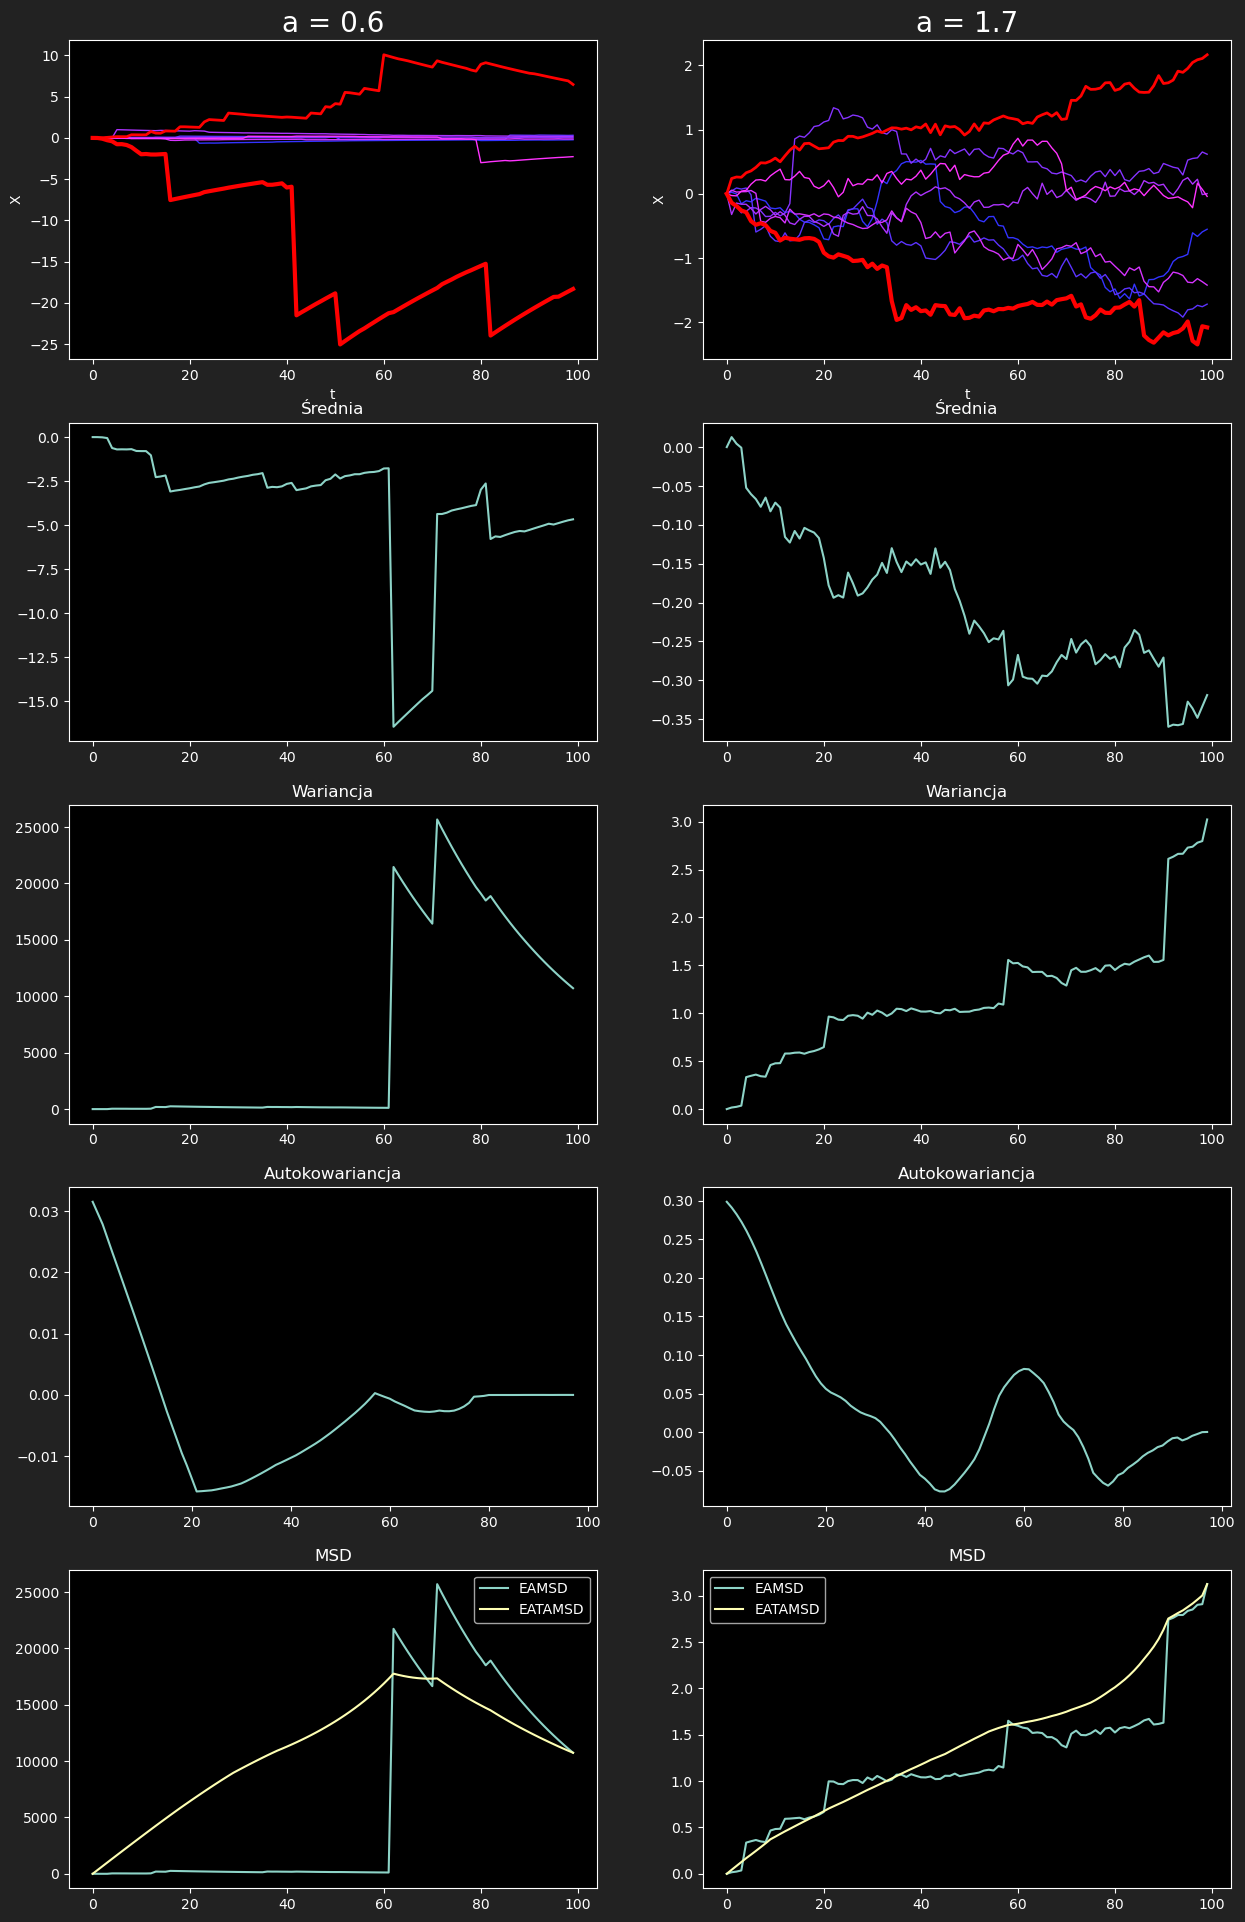

In [40]:
    a_vals = [0.6, 1.7]
    trajectories_count = 1000
    draw_trajectories = 6
    sim_len = 1000
    dt = 0.01

    fig, axes = plt.subplots(5, 2, figsize=(15, 24), facecolor="#222222")

    for i, a in enumerate(tqdm(a_vals, desc=f"Simulating trajectories: ")):
        proc_vals = []

        for j in range(0, trajectories_count):
            sim_v = get_lamperti_transformed_proc(a, 0.0, sim_len, dt)
            proc_vals.append(sim_v)
            if j < draw_trajectories:
                axes[0, i].plot(sim_v, linewidth=1, color=traj_colors[j])


        mean, var, q05, q95 = get_proc_stats(proc_vals)
        a_cod = get_auto_codifference(proc_vals[0])
        a_cov = get_auto_covariance(proc_vals[0])
        eamsd, eatamsd = get_msd(proc_vals)

        axes[0, i].plot(q05, color="red", label="Linie kwantylowe", linewidth=3)
        axes[0, i].plot(q95, color="red", linewidth=2)
        axes[0, i].set_xlabel("t")
        axes[0, i].set_ylabel("X")
        axes[0, i].set_title(f"a = {a}", fontsize=20)

        axes[1, i].plot(mean)
        axes[1, i].set_title("Średnia")
        
        axes[2, i].plot(var)
        axes[2, i].set_title("Wariancja")

        axes[3, i].plot(a_cov)
        axes[3, i].set_title("Autokowariancja")

        axes[4, i].plot(eamsd, label="EAMSD")
        axes[4, i].plot(eatamsd, label="EATAMSD")
        axes[4, i].set_title("MSD")
        axes[4, i].legend()


    plt.show()

## Zagadnienia (ułamkowy proces Ornsteina-Uhlenbecka)

#### Czy proces jest stacjonarny?


#### Czy przyrosty procesu są stacjonarne?


#### Jaki jest rozkład procesu w ustalonej chwili czasu? Jaki jest rozkład przyrostów?


#### Czy EATAMSD pokrywa się z EAMSD?


#### Czy proces jest samopodobny? Czy jego przyrosty są samopodobne?

### Ułamkowy stabilny ruch Levy'ego

## Zadanie 2

### Symetryczny stabilny ruch Levy'ego

In [41]:
@njit
def rand_a_stable(a, B, sigma, delta):
    theta = np.random.uniform()*math.pi - math.pi/2
    theta_0 = np.arctan(B*np.tan(math.pi*a/2))/a
    W = np.random.exponential()

    if a == 1:
        Z = 2/math.pi * ( (math.pi/2 + B*theta)*np.tan(theta) - B*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + B*theta)) )
    else:
        Z = np.sin(a*(theta_0 + theta)) / ((np.cos(a*theta_0)*np.cos(theta))**(1/a)) * ( np.cos(a*theta_0 + (a - 1)*theta) / W )**((1 - a)/a)

    if a == 1:
        return sigma*Z + (delta + B * 2/math.pi * sigma * np.log(sigma))
    else:
        return sigma*Z + delta


@njit
def get_symmetric_stable_levy_process(start_val, a, proc_len, dt):
    sigma = (dt)**(1/a)
    B = 0.0

    increments = np.array( [ rand_a_stable(a, B, sigma, 0.0) for t in range(0, proc_len)] )
    return (np.cumsum(increments) + start_val)


@njit
def get_exit_time(a, b, proc_vals):
    for t, v in enumerate(proc_vals):
        if v < a:
            return t, True
        elif v > b:
            return t, False
    return None, False

a = 2.0:   0%|          | 0/100 [00:00<?, ?it/s]

a = 0.03: 100%|██████████| 100/100 [00:00<00:00, 316.55it/s]


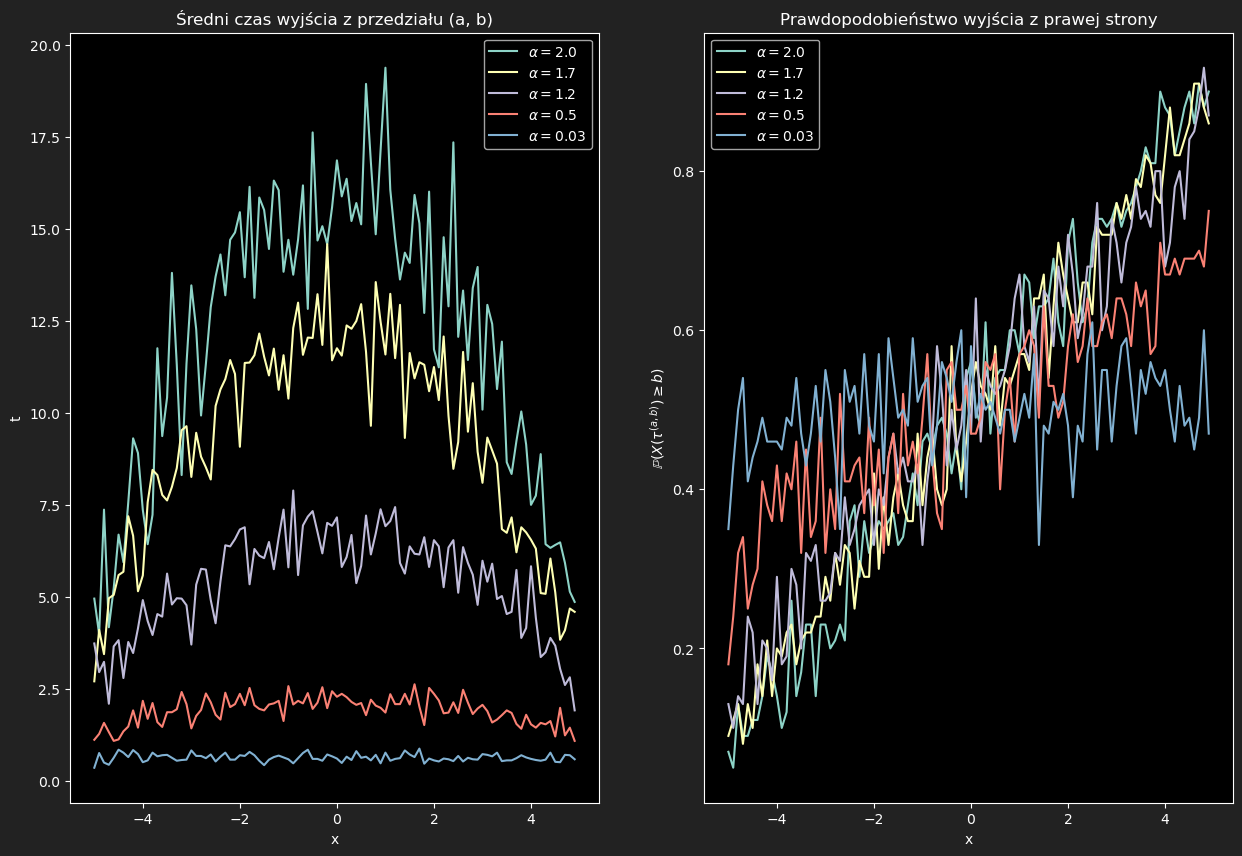

In [46]:
def test_exit_time(a): 
    processes_count = 10000
    proc_len = 100
    dt = 1.0

    range_min = -5.0
    range_max = 5.0
    range_incr = 0.1

    start_vals = np.arange(range_min, range_max, range_incr)
    exit_times = np.zeros_like(start_vals)
    p_exit_right = np.zeros_like(start_vals)


    for i, start_val in enumerate(tqdm(start_vals, desc=f"a = {a}: ")):
        exit_time = 0.0
        p_exit_left = 0.0

        for _ in range(0, processes_count):
            e = None
            last_end_val = start_val

            while e == None:
                proc_vals = get_symmetric_stable_levy_process(last_end_val, a, proc_len, dt)
                e, has_exited_left = get_exit_time(range_min, range_max, proc_vals)
                if e == None:
                    last_end_val = proc_vals[-1]
                    exit_time += proc_len
            
            exit_time += e
            p_exit_left += int(has_exited_left)

        
        exit_times[i] = exit_time/processes_count
        p_exit_right[i] = 1.0 - p_exit_left/processes_count
    
    return start_vals, exit_times, p_exit_right

a_vals = [2.0, 1.7, 1.2, 0.5, 0.03]

fig, axes = plt.subplots(1, 2, figsize=(15, 10), facecolor="#222222")

axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].set_title("Średni czas wyjścia z przedziału (a, b)")

axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$\mathbb{P}(X(\tau^{(a,b)}) \geq b)$")
axes[1].set_title("Prawdopodobieństwo wyjścia z prawej strony")

for a in a_vals:
    s, e, p = test_exit_time(a)

    axes[0].plot(s, e, label=f"$\\alpha={a}$")
    axes[1].plot(s, p, label=f"$\\alpha={a}$")

axes[0].legend()
axes[1].legend()
plt.show()

## Wnioski

* Funkcja średniego czasu wyjścia z przedziału `[a, b]` ma kształt paraboliczny z ekstremum ulokowanym w środku przedziału. Wartość ekstremum tej funkcji maleje wraz z malejącym parametrem `alpha`.
* Prawdopodobieństwo wyjścia z przedziału z danej strony jest liniowo zależne od początkowej odległości od tego brzegu.
* Biblioteka `numba` oraz dekorator `@njit` znacząco pomogły w przyspieszeniu działania kodu. Użycie jej powoduje kompilację tak oznaczonej funkcji przy pierwszym jej wywołaniu. Sprawia to, że funkcje wywoływane zaledwie parę razy są wolniejsze (dochodzi czas kompilacji), ale przy wielu wywołaniach czas czas każdego z nich jest znacząco mniejszy, co pozwala znacznie przyspieszyć działanie programu. Pozwoliło to policzyć dosyć duże liczby trajektorii do estymacji - w tym zadaniu po 10000 trajektorii, każda długości 100 w około 30s.